# Chen-Pelger-Zhu Academic Asset Pricing Dataset

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`
**Section Reference**: Section 4.1 (The Point-in-Time Pipeline)

## Purpose

This notebook introduces the Chen-Pelger-Zhu (2020) academic dataset, which provides
a standardized benchmark for comparing ML models in asset pricing. With ~1.2M stock-month
observations and 46 firm characteristics, this anonymized dataset enables reproducible
research without requiring WRDS access.

## Learning Objectives

After completing this notebook, you will be able to:
- Load and explore the Chen-Pelger-Zhu academic dataset
- Understand the 46 firm characteristics and their categories
- Recognize the cross-sectional rank normalization applied to features
- Understand the train/valid/test split methodology
- Know the limitations (no asset IDs = no backtesting possible)

## Cross-References

- **Downstream**: Ch11 `case_studies/us_firm_characteristics/05_linear.py`, Ch12 `06_gbm.py`
- **Related**: Ch14 `case_studies/us_firm_characteristics/08_latent_factors.py`
- **Synthesis**: `case_studies/us_firm_characteristics/10_model_analysis.py`

## Prerequisites

Download the dataset before running this notebook:
```bash
python data/equities/firm_characteristics/download.py
```

## Data Source

| Attribute | Value |
|-----------|-------|
| **Paper** | "Deep Learning in Asset Pricing" (Chen, Pelger, Zhu, 2021) |
| **Repository** | https://github.com/jasonzy121/Deep_Learning_Asset_Pricing |
| **Observations** | ~1.2M stock-months |
| **Features** | 46 firm characteristics (rank-normalized) |
| **Returns** | Next-month excess returns (raw, not normalized) |
| **Period** | 1967-2016 (50 years) |
| **Identifiers** | **None** (fully anonymized) |

## Data Construction (from paper Section III.A)

### Stock Universe
- Source: All securities on CRSP (~31,000 stocks)
- Only stocks with all 46 characteristics available are included
- This removes predominantly small-cap stocks with missing data
- The released dataset contains ~2,000 stocks per month on average

### 46 Firm Characteristics
Characteristics are sourced from:
1. Kenneth French Data Library
2. Freyberger, Neuhierl, and Weber (2020)

**Categories** (cf. Table A.II in paper; this notebook groups them as):
- **Valuation**: BEME, E2P, S2P, CF2P, D2P, A2ME, Q
- **Profitability**: ROA, ROE, PROF, OP, PM, PCM, NI, RNA
- **Investment**: Investment, NOA, OA, AC, AT, D2A
- **Momentum / past returns**: r2_1, r12_2, r12_7, r36_13, ST_REV, LT_Rev, Rel2High
- **Risk**: Beta, MktBeta, IdioVol, Variance, Resid_Var
- **Liquidity / Size**: LME, LTurnover, Spread, SUV
- **Leverage**: Lev, OL, FC2Y, C, CF, DPI2A
- **Other**: ATO, CTO, SGA2S

**Construction**:
- Yearly variables: Updated end of June (Fama-French convention)
- Monthly variables: Updated end of month for use in next month
- All from CRSP/Compustat accounting data or CRSP past returns

### 178 Macroeconomic Time Series
1. 124 from FRED-MD database (McCracken and Ng, 2016)
2. 46 cross-sectional medians of firm characteristics
3. 8 equity premium predictors from Welch and Goyal (2007)

### Cross-Sectional Rank Normalization
Following Kelly, Pruitt, Su (2019), Kozak, Nagel, Santosh (2020):
- Each characteristic ranked cross-sectionally each month
- Converted to quantiles in [-0.5, +0.5] range
- Handles different scales and reduces outlier impact

## Key Concepts

- **Cross-sectional rank normalization**: Features scaled to [-0.5, +0.5] each month
- **Next-month return prediction**: `ret` is the raw excess return to be predicted (not normalized)
- **No asset identifiers**: Individual stocks cannot be tracked over time

---

In [1]:
"""Chen-Pelger-Zhu Academic Asset Pricing Dataset — explore anonymized firm characteristics for ML benchmarking."""

import warnings

warnings.filterwarnings("ignore")

from datetime import datetime

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import statsmodels.api as sm

from data import load_firm_characteristics
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_diverging

# Importing utils.style registers and activates the ML4T Plotly template
# (palette, gridlines, fonts) repo-wide; px/go figures below inherit its colorway.

In [2]:
# Production defaults — Papermill injects overrides for CI
SEED = 42

In [3]:
set_global_seeds(SEED)

---

## Section 1: Data Overview

The Chen-Pelger-Zhu dataset provides a clean, standardized benchmark for comparing
ML approaches to return prediction. All features are cross-sectionally rank-normalized
each month, eliminating scale differences and reducing outlier impact.

In [4]:
# Load full dataset with split labels
df = load_firm_characteristics(split="all")

print(f"Total observations: {len(df):,}")
print(f"Columns: {len(df.columns)}")
df.columns

Total observations: 1,218,555
Columns: 49


['ret',
 'A2ME',
 'AC',
 'AT',
 'ATO',
 'BEME',
 'Beta',
 'C',
 'CF',
 'CF2P',
 'CTO',
 'D2A',
 'D2P',
 'DPI2A',
 'E2P',
 'FC2Y',
 'IdioVol',
 'Investment',
 'Lev',
 'LME',
 'LT_Rev',
 'LTurnover',
 'MktBeta',
 'NI',
 'NOA',
 'OA',
 'OL',
 'OP',
 'PCM',
 'PM',
 'PROF',
 'Q',
 'r2_1',
 'r12_2',
 'r12_7',
 'r36_13',
 'Rel2High',
 'Resid_Var',
 'RNA',
 'ROA',
 'ROE',
 'S2P',
 'SGA2S',
 'Spread',
 'ST_REV',
 'SUV',
 'Variance',
 'timestamp',
 'split']

In [5]:
# Check date range and split distribution
date_stats = df.group_by("split").agg(
    pl.col("timestamp").min().alias("start"),
    pl.col("timestamp").max().alias("end"),
    pl.len().alias("n_obs"),
)
date_stats.sort("start")

split,start,end,n_obs
str,date,date,u32
"""train""",1967-01-31,1989-12-29,414025
"""valid""",1990-01-31,1999-12-31,307094
"""test""",2000-01-31,2016-12-30,497436



Observations per month:
  Min: 430
  Max: 2826
  Mean: 2031


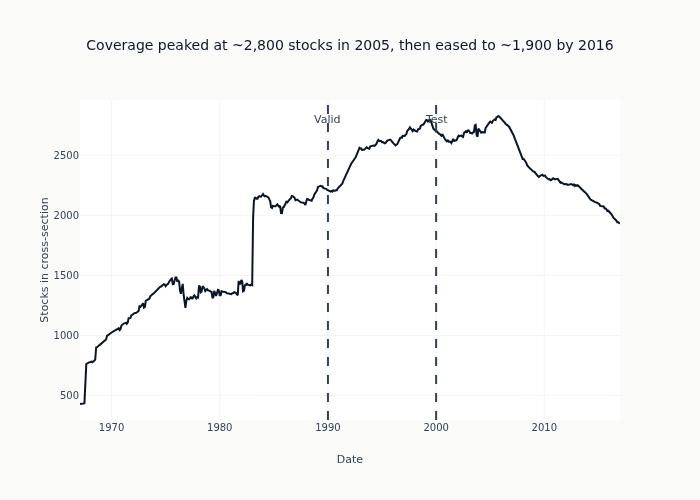

In [6]:
# Observations per month
monthly_counts = (
    df.group_by("timestamp")
    .len()
    .sort("timestamp")
    .with_columns(
        pl.col("timestamp").dt.year().alias("year"),
    )
)

print("\nObservations per month:")
print(f"  Min: {monthly_counts['len'].min()}")
print(f"  Max: {monthly_counts['len'].max()}")
print(f"  Mean: {monthly_counts['len'].mean():.0f}")

# Plot observations over time
fig = px.line(
    monthly_counts.to_pandas(),
    x="timestamp",
    y="len",
    title="Coverage peaked at ~2,800 stocks in 2005, then eased to ~1,900 by 2016",
    labels={"len": "Stocks in cross-section", "timestamp": "Date"},
    color_discrete_sequence=[COLORS["blue"]],
)
# Split boundaries (train | valid | test), drawn in the neutral palette color
fig.add_vline(x=datetime(1990, 1, 1), line_dash="dash", line_color=COLORS["neutral"])
fig.add_vline(x=datetime(2000, 1, 1), line_dash="dash", line_color=COLORS["neutral"])
fig.add_annotation(
    x=datetime(1990, 1, 1),
    y=2800,
    text="Valid",
    showarrow=False,
    font=dict(color=COLORS["neutral"]),
)
fig.add_annotation(
    x=datetime(2000, 1, 1), y=2800, text="Test", showarrow=False, font=dict(color=COLORS["neutral"])
)
fig.show()

---

## Section 2: Characteristic Taxonomy

The 46 firm characteristics span multiple categories that capture different dimensions
of stock behavior: valuation, profitability, investment, momentum, risk, and market metrics.

All characteristics are cross-sectionally rank-normalized each month to values in [-0.5, +0.5].

In [7]:
# Define characteristic categories
CHARACTERISTIC_CATEGORIES = {
    "Valuation": ["BEME", "E2P", "S2P", "CF2P", "D2P", "A2ME", "Q"],
    "Profitability": ["ROA", "ROE", "PROF", "OP", "PM", "PCM", "NI", "RNA"],
    "Investment": ["Investment", "NOA", "OA", "AC", "AT", "D2A"],
    "Momentum": ["r2_1", "r12_2", "r12_7", "r36_13", "ST_REV", "LT_Rev", "Rel2High"],
    "Risk": ["Beta", "MktBeta", "IdioVol", "Variance", "Resid_Var"],
    "Liquidity/Size": ["LME", "LTurnover", "Spread", "SUV"],
    "Leverage": ["Lev", "OL", "FC2Y", "C", "CF", "DPI2A"],
    "Other": ["ATO", "CTO", "SGA2S"],
}

# Print category summary
print("Characteristic Categories:")
print("=" * 60)
total = 0
for category, features in CHARACTERISTIC_CATEGORIES.items():
    print(f"\n{category} ({len(features)} features):")
    print(f"  {', '.join(features)}")
    total += len(features)
print(f"\nTotal: {total} characteristics")

Characteristic Categories:

Valuation (7 features):
  BEME, E2P, S2P, CF2P, D2P, A2ME, Q

Profitability (8 features):
  ROA, ROE, PROF, OP, PM, PCM, NI, RNA

Investment (6 features):
  Investment, NOA, OA, AC, AT, D2A

Momentum (7 features):
  r2_1, r12_2, r12_7, r36_13, ST_REV, LT_Rev, Rel2High

Risk (5 features):
  Beta, MktBeta, IdioVol, Variance, Resid_Var

Liquidity/Size (4 features):
  LME, LTurnover, Spread, SUV

Leverage (6 features):
  Lev, OL, FC2Y, C, CF, DPI2A

Other (3 features):
  ATO, CTO, SGA2S

Total: 46 characteristics


In [8]:
# Distribution of each characteristic (confirming rank normalization)
feature_cols = [c for c in df.columns if c not in ["timestamp", "ret", "split"]]

# Compute statistics efficiently using Polars - no loops needed
sample_features = feature_cols[:10]
stats_df = df.select(sample_features).describe()
stats_df.filter(pl.col("statistic").is_in(["min", "max", "mean", "std"]))

statistic,A2ME,AC,AT,ATO,BEME,Beta,C,CF,CF2P,CTO
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""mean""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""std""",0.288817,0.288817,0.288817,0.288817,0.288817,0.288817,0.288817,0.288817,0.288817,0.288817
"""min""",-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5
"""max""",0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5


---

## Section 3: Correlation Structure

Understanding correlations between characteristics helps identify redundant features
and understand the factor structure in the data.

In [9]:
# Compute correlation matrix
corr_data = df.select(feature_cols).to_numpy()
corr_matrix = np.corrcoef(corr_data, rowvar=False)

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        if abs(corr_matrix[i, j]) > 0.5:
            high_corr_pairs.append(
                {
                    "feature_1": feature_cols[i],
                    "feature_2": feature_cols[j],
                    "correlation": corr_matrix[i, j],
                }
            )

high_corr_df = pl.DataFrame(high_corr_pairs).sort("correlation", descending=True)
high_corr_df

feature_1,feature_2,correlation
str,str,f64
"""FC2Y""","""SGA2S""",0.985961
"""Resid_Var""","""Variance""",0.973422
"""IdioVol""","""Resid_Var""",0.899009
"""AC""","""OA""",0.876956
"""IdioVol""","""Variance""",0.87659
…,…,…
"""AT""","""Resid_Var""",-0.54109
"""LME""","""Resid_Var""",-0.584554
"""Q""","""S2P""",-0.626317


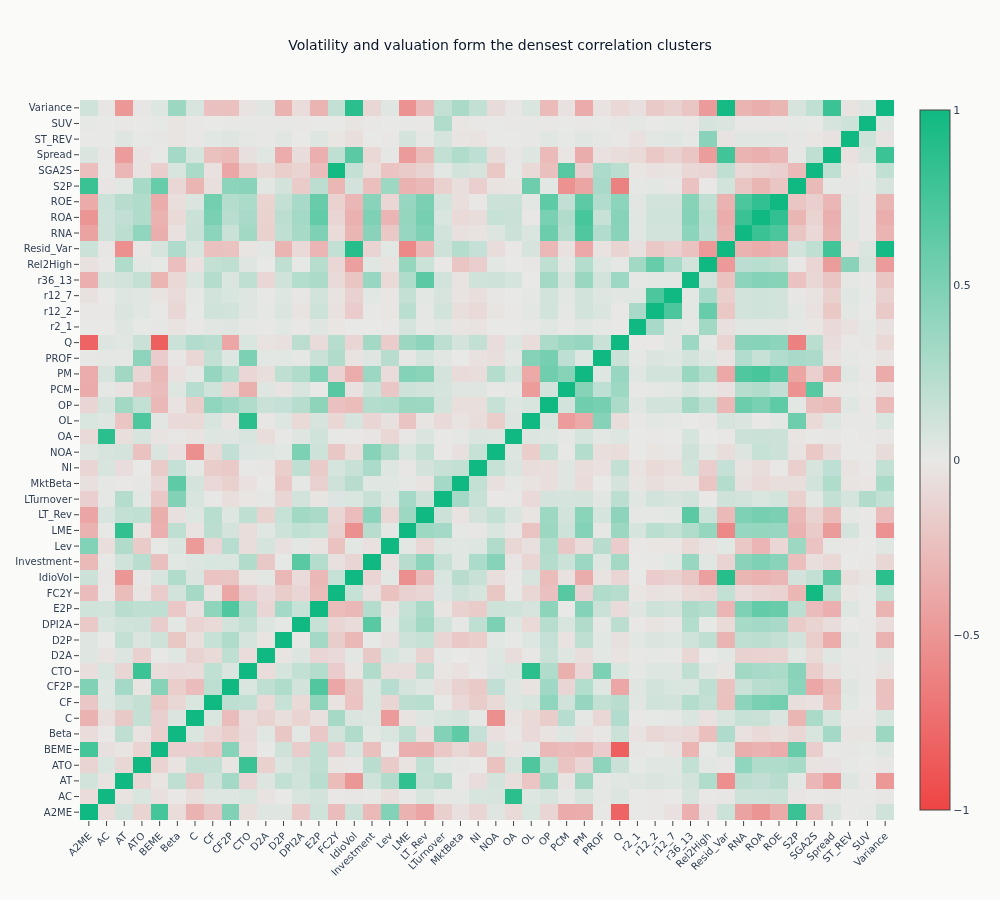

In [10]:
# Correlation heatmap on the ML4T diverging scale (negative -> neutral -> positive)
_div = ml4t_diverging()
fig = go.Figure(
    data=go.Heatmap(
        z=corr_matrix,
        x=feature_cols,
        y=feature_cols,
        colorscale=[[0.0, _div[0]], [0.5, _div[1]], [1.0, _div[2]]],
        zmid=0,
        zmin=-1,
        zmax=1,
    )
)
fig.update_layout(
    title="Volatility and valuation form the densest correlation clusters",
    width=1000,
    height=900,
    xaxis_tickangle=-45,
)
fig.show()

---

## Section 4: Predictive Relationships

The key question: how do characteristics relate to next-month returns?
These Information Coefficients (ICs) measure the predictive power of each feature.

We compute monthly cross-sectional ICs (one rank correlation per month) and
average across months — the Fama-MacBeth template. The naive t-statistic on
this series assumes monthly ICs are i.i.d., but adjacent months share
slow-moving common factors that induce autocorrelation. The reported
significance test uses Newey-West (HAC) standard errors on the time series
of monthly ICs; for comparison we also keep the i.i.d. t-statistic.

In [11]:
# Step 1: Compute IC (correlation with returns) for each characteristic, per month.
# Sort by timestamp before dropping it: the Newey-West HAC t-stat below reads this
# as a time series, so the monthly ICs must be in chronological order. group_by emits
# groups in a non-deterministic order, which would scramble the autocovariance the HAC
# correction is built on (and make the t-stat non-reproducible run to run).
monthly_ics = (
    df.group_by("timestamp")
    .agg([pl.corr(col, "ret").alias(col) for col in feature_cols])
    .sort("timestamp")
    .drop("timestamp")
)

# Step 2: Compute mean IC, i.i.d. t-stat, and Newey-West HAC t-stat across months
n_months = len(monthly_ics)
# Newey-West lag selection: floor(4 * (T/100)^(2/9)); ~6 for monthly series of
# this length. Use 12 to be conservative against the annual cycle in factor returns.
nw_maxlags = 12
ic_stats = []
for col in feature_cols:
    ic_values = monthly_ics[col].to_numpy()
    ic_values = ic_values[~np.isnan(ic_values)]  # constant-feature months
    mean_ic = float(np.mean(ic_values))
    std_ic = float(np.std(ic_values, ddof=1))
    t_stat_iid = mean_ic / (std_ic / np.sqrt(len(ic_values)))
    # HAC t-stat: regress IC_t on a constant with Newey-West covariance.
    nw = sm.OLS(ic_values, np.ones(len(ic_values))).fit(
        cov_type="HAC", cov_kwds={"maxlags": nw_maxlags}
    )
    t_stat_nw = float(nw.tvalues[0])
    ic_stats.append(
        {
            "feature": col,
            "IC": mean_ic,
            "IC_std": std_ic,
            "t_stat_iid": t_stat_iid,
            "t_stat_NW": t_stat_nw,
            "abs_IC": abs(mean_ic),
        }
    )

ic_df = pl.DataFrame(ic_stats).sort("IC", descending=True)

print(
    f"Cross-sectional IC across {n_months} monthly cross-sections "
    f"(|t_NW| > 2 ≈ significant; Newey-West with {nw_maxlags} lags):"
)
ic_df

Cross-sectional IC across 600 monthly cross-sections (|t_NW| > 2 ≈ significant; Newey-West with 12 lags):


feature,IC,IC_std,t_stat_iid,t_stat_NW,abs_IC
str,f64,f64,f64,f64,f64
"""r12_2""",0.027936,0.117241,5.836497,5.524161,0.027936
"""SUV""",0.026735,0.052936,12.370895,9.893822,0.026735
"""BEME""",0.022178,0.08065,6.735855,5.241187,0.022178
"""S2P""",0.022041,0.086982,6.206825,4.311492,0.022041
"""r12_7""",0.021581,0.088201,5.993429,5.311766,0.021581
…,…,…,…,…,…
"""Investment""",-0.017629,0.068088,-6.34191,-4.886888,0.017629
"""Q""",-0.022443,0.083108,-6.614667,-4.796797,0.022443
"""Beta""",-0.022914,0.134093,-4.185656,-3.801968,0.022914


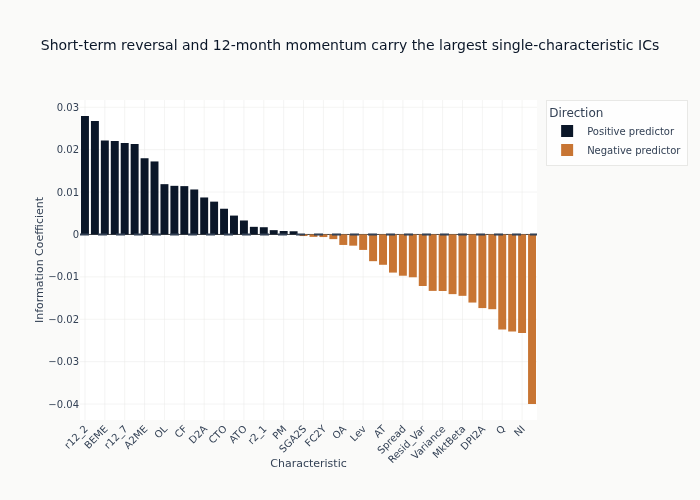

In [12]:
# Visualize ICs by category
ic_with_category = []
for row in ic_df.iter_rows(named=True):
    category = "Other"
    for cat, features in CHARACTERISTIC_CATEGORIES.items():
        if row["feature"] in features:
            category = cat
            break
    ic_with_category.append({**row, "category": category})

ic_cat_df = pl.DataFrame(ic_with_category).with_columns(
    pl.when(pl.col("IC") > 0)
    .then(pl.lit("Positive predictor"))
    .otherwise(pl.lit("Negative predictor"))
    .alias("Direction")
)

# 8 characteristic categories exceed the ML4T palette's distinct-color budget, so
# color encodes the sign of the relationship (the point of the figure); the x-axis
# names the individual characteristic.
fig = px.bar(
    ic_cat_df.to_pandas(),
    x="feature",
    y="IC",
    color="Direction",
    color_discrete_map={
        "Positive predictor": COLORS["blue"],
        "Negative predictor": COLORS["copper"],
    },
    category_orders={"Direction": ["Positive predictor", "Negative predictor"]},
    title="Short-term reversal and 12-month momentum carry the largest single-characteristic ICs",
    labels={"IC": "Information Coefficient", "feature": "Characteristic"},
)
fig.update_layout(xaxis_tickangle=-45, height=500)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])
fig.show()

---

## Section 5: Return Distribution

The target variable `ret` represents next-month excess returns. Unlike the
characteristics, returns are **not** rank-normalized — they remain in their
original scale, as required for economic interpretation of predictions.

In [13]:
# Return statistics by split
return_stats = df.group_by("split").agg(
    pl.col("ret").mean().alias("mean"),
    pl.col("ret").std().alias("std"),
    pl.col("ret").min().alias("min"),
    pl.col("ret").max().alias("max"),
    pl.col("ret").quantile(0.25).alias("q25"),
    pl.col("ret").quantile(0.75).alias("q75"),
)
return_stats

split,mean,std,min,max,q25,q75
str,f64,f64,f64,f64,f64,f64
"""valid""",0.011198,0.179938,-0.960633,18.9975,-0.071549,0.072706
"""train""",0.007274,0.132483,-0.8555,6.379115,-0.064301,0.06654
"""test""",0.011174,0.170281,-0.956084,10.3397,-0.065034,0.073072


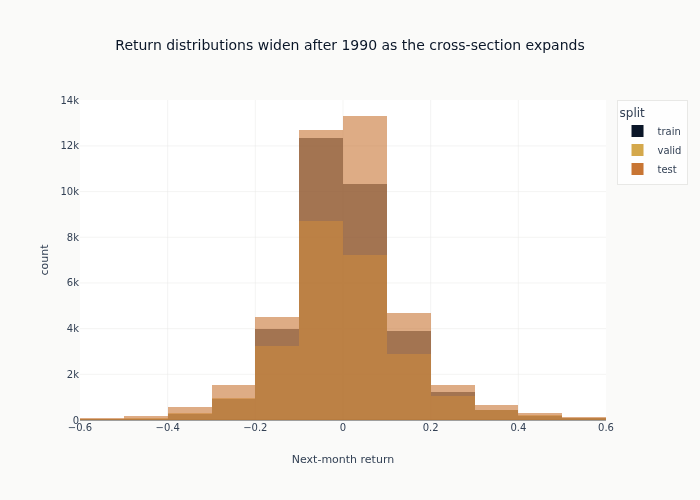

In [14]:
# Return distribution
sample_size = min(100_000, len(df))
# Clip to +/-60% so the distribution shape is visible; a few extreme outliers
# (max next-month return ~+1900% in the valid split) otherwise flatten every bar
# into a single spike at zero and hide the very widening the figure is about.
fig = px.histogram(
    df.sample(n=sample_size, seed=SEED).to_pandas(),  # Convert for Plotly compatibility
    x="ret",
    color="split",
    nbins=120,
    range_x=[-0.6, 0.6],
    category_orders={"split": ["train", "valid", "test"]},
    color_discrete_sequence=[COLORS["blue"], COLORS["amber"], COLORS["copper"]],
    title="Return distributions widen after 1990 as the cross-section expands",
    labels={"ret": "Next-month return", "count": "Frequency"},
    opacity=0.6,
    barmode="overlay",
)
fig.show()

---

## Section 6: Macro Indicators (Optional Companion Data)

The Chen-Pelger-Zhu paper pairs the firm characteristics with 178 macroeconomic
time series — 124 from FRED-MD (McCracken and Ng, 2016), 46 cross-sectional
medians of firm characteristics, and 8 equity-premium predictors from Welch and
Goyal (2007). Conditional models such as SDF-GAN (Ch14) consume them as state
variables.

The shipped academic parquet contains characteristics + returns only; macro
columns ship separately. Calling `include_macro=True` is a no-op against the
shipped file. To assemble the macro panel for conditional models, follow the
instructions in the original paper repository
(https://github.com/jasonzy121/Deep_Learning_Asset_Pricing) and merge on
`timestamp`.

In [15]:
df_with_macro = load_firm_characteristics(split="all", include_macro=True)
macro_cols = [c for c in df_with_macro.columns if c.startswith("macro_")]
print(f"macro_* columns in shipped dataset: {len(macro_cols)}")

macro_* columns in shipped dataset: 0


---

## Section 7: Limitations and Use Cases

### What This Dataset IS Good For

1. **Benchmarking ML models**: Compare linear, tree, and neural network approaches
2. **Hyperparameter optimization studies**: Large sample size enables thorough HPO
3. **Reproducible research**: No WRDS access required
4. **Educational purposes**: Clean, standardized dataset for learning

### What This Dataset IS NOT Good For

1. **Backtesting strategies**: No asset identifiers = cannot track stocks over time
2. **Portfolio construction**: Cannot form portfolios without knowing which returns belong together
3. **Transaction cost analysis**: No price levels, only normalized returns
4. **Fundamental analysis**: Characteristics are anonymized and normalized

### Key Insight

This dataset answers: **"Can ML predict cross-sectional return variation from characteristics?"**

It does NOT answer: **"Can this prediction be monetized in practice?"**

For practical trading strategies, see the ETF, Crypto, and Futures case studies
throughout this book.

## Key Takeaways

1. The Chen-Pelger-Zhu dataset provides a clean benchmark for comparing ML models in asset pricing.
2. Cross-sectional rank normalization places every characteristic in $[-0.5, +0.5]$, which removes scale differences and tames outliers.
3. Single-characteristic ICs are small ($|\bar{\rho}| \le 0.04$) but several remain significant after Newey-West correction for autocorrelation in the monthly IC series ($|t_{\text{NW}}| > 5$ for the leading signals — SUV, ST_REV, NI, BEME, r12_2).
4. Strong within-category correlations (e.g., $|\rho| > 0.8$ between BEME / Q / A2ME) motivate regularised linear models and tree ensembles that handle collinearity natively.
5. **Limitation**: no asset identifiers — this dataset supports prediction-accuracy studies, not backtesting.

**Next**: See `case_studies/us_firm_characteristics/` for ML models applied to this data.